#Identitas Diri

NIM  : 221351023<br>
Nama : Azzukhuf Fathan Amar<br>
Kelas: Pagi C<br>
Matkul: ML (Machine Learning)

# Business Understanding

## Project Domain

Agriculture / Food Safety – Mushroom Classification<br>
Proyek ini berada di domain pertanian dan keamanan pangan, dengan fokus pada klasifikasi jamur berdasarkan karakteristik fisiknya untuk menentukan apakah jamur tersebut dapat dimakan atau beracun.



## Problem Statements

Banyak orang yang tidak bisa membedakan antara jamur yang dapat dimakan dan jamur yang beracun hanya berdasarkan ciri fisiknya.

Kesalahan dalam mengidentifikasi jamur dapat menyebabkan risiko kesehatan yang serius atau bahkan kematian.

Tidak semua orang memiliki akses ke ahli mikologi untuk membantu mengklasifikasikan jamur di lapangan.

## Goals

1. Membangun model pembelajaran mesin yang dapat mengklasifikasikan jamur sebagai edible (dapat dimakan) atau poisonous (beracun) berdasarkan fitur visual dan fisik jamur.

2. Memberikan alat bantu berbasis data untuk meningkatkan keamanan konsumsi jamur.

3. Mengedukasi masyarakat dan petani mengenai ciri-ciri jamur beracun melalui analisis data.



## Solution Statements

1. Menggunakan dataset jamur yang berisi fitur-fitur seperti warna topi, permukaan batang, cincin, bau, dan lainnya untuk melatih model klasifikasi.

2. Menerapkan algoritma pembelajaran mesin (seperti Decision Tree, Random Forest, SVM, dll.) untuk membedakan jamur beracun dan dapat dimakan.

3. Mengevaluasi performa model menggunakan metrik seperti akurasi, precision, recall, dan confusion matrix.

4. Menghasilkan sistem rekomendasi atau alat prediksi yang dapat digunakan oleh pengguna untuk memeriksa jenis jamur hanya dengan memasukkan ciri-cirinya.

# Data Understanding

## Import data dari kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"azzukhruffathanamar","key":"c75b2855cf0ae477b8c76d2acbdbbd1b"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d uciml/mushroom-classification

Dataset URL: https://www.kaggle.com/datasets/uciml/mushroom-classification
License(s): CC0-1.0


In [ ]:
!mkdir mushroom-classification
!unzip mushroom-classification.zip -d mushroom-classification
!ls mushroom-classification

Archive:  mushroom-classification.zip
  inflating: mushroom-classification/mushrooms.csv  
mushrooms.csv


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model

## Exploratory Data Analysis

In [ ]:
df = pd.read_csv('mushroom-classification/mushrooms.csv')

In [ ]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [ ]:
df['class'].value_counts()

,count
class,
e,4208
p,3916


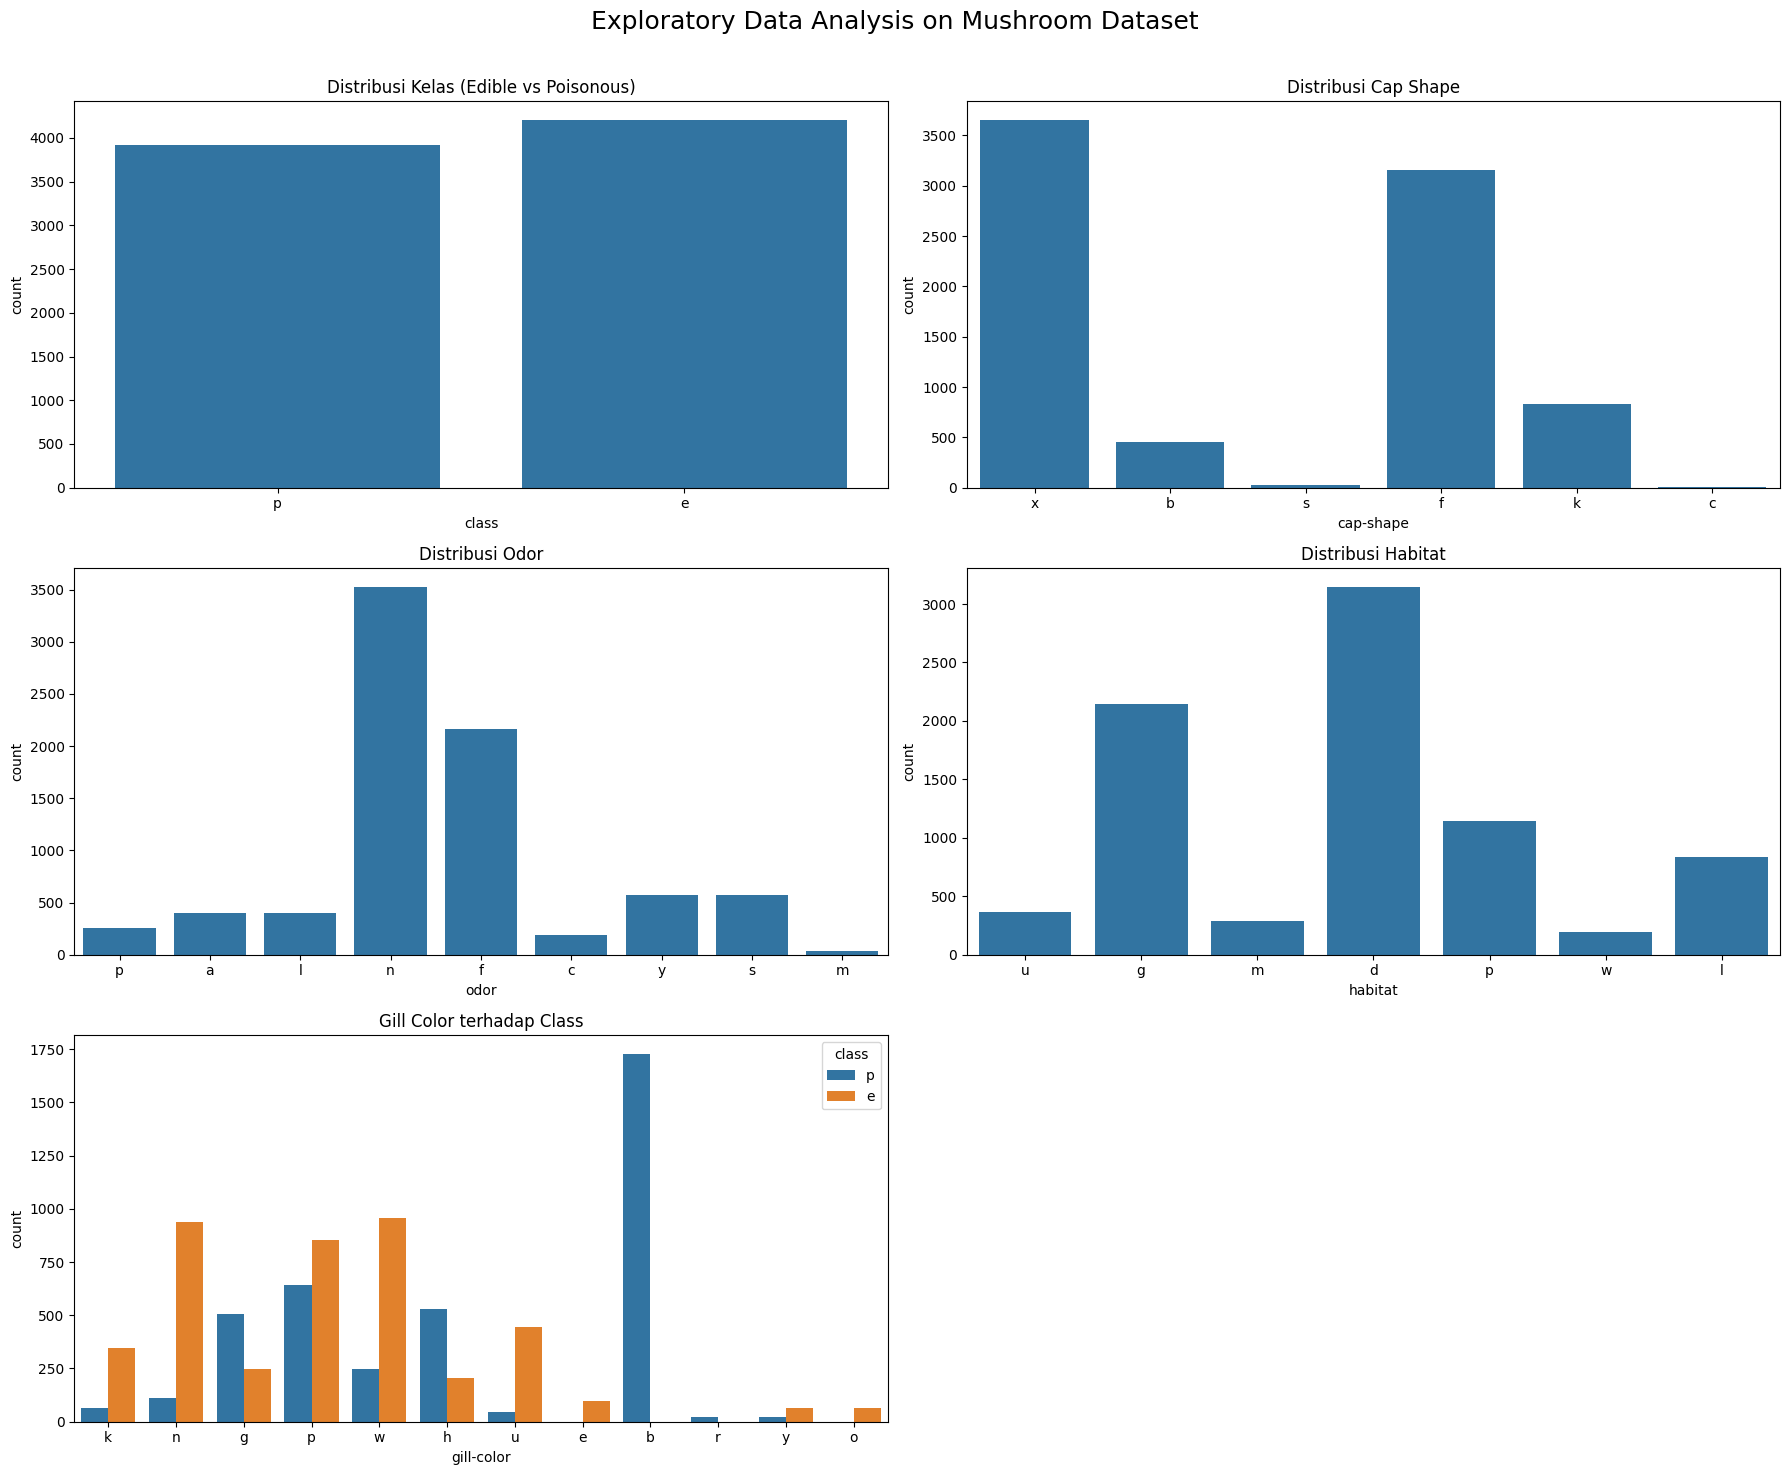

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle("Exploratory Data Analysis on Mushroom Dataset", fontsize=18)

# 1. Distribusi target class
sns.countplot(x="class", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Distribusi Kelas (Edible vs Poisonous)")

# 2. Distribusi cap-shape/bentuk topi
sns.countplot(x="cap-shape", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Distribusi Cap Shape")

# 3. Distribusi odor/bau
sns.countplot(x="odor", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Distribusi Odor")

# 4. Distribusi habitat
sns.countplot(x="habitat", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Distribusi Habitat")

# 5. Perbandingan gill-color terhadap class
sns.countplot(x="gill-color", hue="class", data=df, ax=axes[2, 0])
axes[2, 0].set_title("Gill Color terhadap Class")

# Hapus subplot kosong
fig.delaxes(axes[2, 1])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# Data Preparation

In [ ]:
# Pisahkan fitur dan label
X = df.drop('class', axis=1)
y = df['class']

In [ ]:
# Encode semua kolom kategorikal
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Encode y_train and y_test if needed (assuming 'class' is categorical)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [ ]:
# Encode all categorical columns in X_train and X_test
le = LabelEncoder()
for col in X_train.select_dtypes(include=['object']).columns:
    le.fit(pd.concat([X_train[col], X_test[col]], axis=0)) # Fit on combined train and test data for consistent encoding
    X_train[col] = le.transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# Modeling

In [ ]:
model = Sequential()
model.add(Dense(64, input_dim=X.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

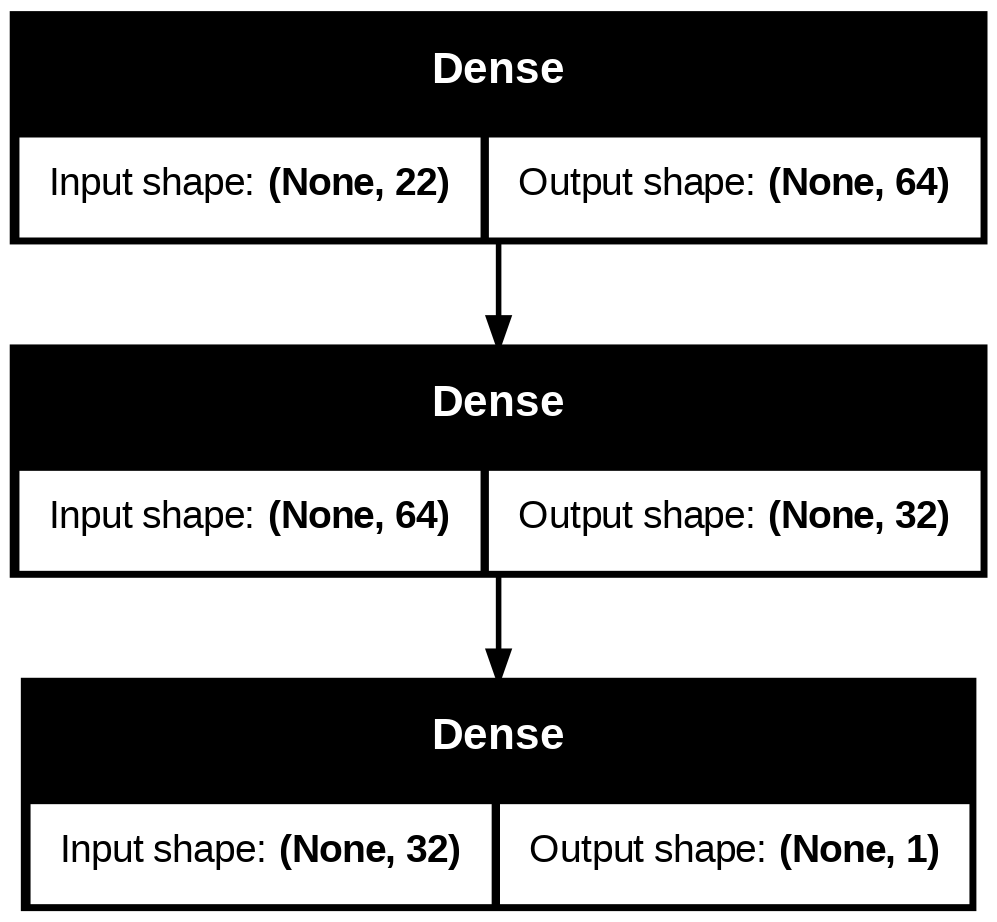

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [ ]:
# Training model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7818 - loss: 0.4711 - val_accuracy: 0.9323 - val_loss: 0.2109
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9303 - loss: 0.2018 - val_accuracy: 0.9615 - val_loss: 0.1258
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9610 - loss: 0.1135 - val_accuracy: 0.9723 - val_loss: 0.0749
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9762 - loss: 0.0740 - val_accuracy: 0.9877 - val_loss: 0.0452
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9901 - loss: 0.0430 - val_accuracy: 0.9938 - val_loss: 0.0268
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0289 - val_accuracy: 0.9938 - val_loss: 0.0224
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9944 - loss: 0.0193 - val_accuracy: 0.9992 - val_loss: 0.0189
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9986 - loss: 0.0135 - val_accuracy: 0.

# Evaluation

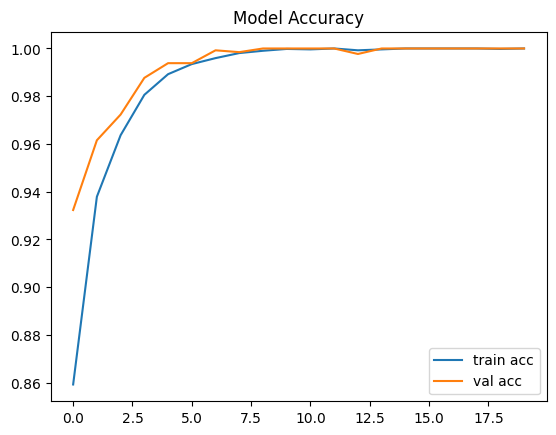

In [ ]:
# Plot loss & accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Model Accuracy')
plt.legend()
plt.show()

In [ ]:
# Test set evaluation
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



# Deployment

In [ ]:
sample = X_test.iloc[0].values.reshape(1, -1)
pred = model.predict(sample)
print("Prediksi:", "Poisonous" if pred > 0.5 else "Edible")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediksi: Edible


## Model Simulation

In [ ]:
import random
index = random.randint(0, len(X_test)-1)
sample = X_test.iloc[index].values.reshape(1, -1)
pred = model.predict(sample)
print("Prediksi:", "Poisonous" if pred > 0.5 else "Edible")
print("Label Asli:", "Poisonous" if y_test[index] == 1 else "Edible")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediksi: Poisonous
Label Asli: Poisonous


## Save Model

In [ ]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('mushroom_ann.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpwx32ws9t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 22), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132615596559632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132615596564816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132615596045328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132615596039184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132615596034576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132615596036496: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']